# Upworthy 헤드라인 A/B 테스트 분석 보고서

---

## 0. 데이터 선정

**데이터셋**: Upworthy Research Archive (exploratory 패키지)
**원 배포처**: Nate Matias 연구팀이 공개한 Upworthy A/B 테스트 아카이브
**아카이브 설명 페이지**: https://upworthy.natematias.com/about-the-archive
**확보 경로**: GitHub 미러(`ains-arch/upworthy-hierarchy` 리포지토리에 원본 zip이 그대로 포함되어 있었음. 공식 배포 채널(Harvard Dataverse 등)이 아닌 제3자 미러이므로, 원 데이터와의 동일성은 확인했으나 출처를 투명하게 밝혀둔다.
**사용 파일**: `upworthy-archive-exploratory-packages-03.12.2020.csv`
**다운로드 날짜**: 2026-07-31

Upworthy는 연구 목적으로 자사가 실제로 운영한 헤드라인 A/B 테스트 기록을 4종류(confirmatory / exploratory / holdout / undeployed)로 나누어 공개했다. 이 중 **exploratory(자유 탐색용으로 공식 지정된 부분)**를 선택했는데, confirmatory는 이미 특정 가설 검증에 쓰인 데이터라 재사용 시 사후적 가설 설정(p-해킹)의 위험이 있고, undeployed는 실제 방문자에게 노출되지 않은 테스트라 분석 대상으로 부적합하기 때문이다.

이 데이터는 Upworthy가 하나의 기사를 발행할 때, 같은 기사에 대해 헤드라인 문구를 2~14개 버전으로 만들어 방문자에게 **무작위로 배정**하여 노출시킨 실제 A/B 테스트 기록이다. 합성/시뮬레이션 데이터가 아니라, 실제 트래픽에서 수집된 진짜 실험 결과다.

---

## 1. 데이터 점검

### 컬럼 설명

| 컬럼명 | 설명 | 분석 사용 여부 |
|---|---|---|
| `clickability_test_id` | 실험(테스트) ID — 같은 값이면 같은 기사에 대해 동시에 진행된 헤드라인 묶음 | **사용** (그룹 묶는 키) |
| `headline` | 실제로 A/B 테스트된 헤드라인 텍스트 (처치 변수) | **사용** |
| `impressions` | 해당 헤드라인 버전에 노출된 방문자 수 (표본 크기) | **사용** |
| `clicks` | 그 중 클릭한 방문자 수 (성공 횟수) | **사용** |
| `test_week` | 실험이 진행된 연도-주차 | 참고용 |
| `significance` | Upworthy가 자체 계산한 유의성 지표(0~100) | 참고·비교용 (그대로 인용하지 않음) |
| `first_place` | 해당 헤드라인이 그 실험에서 CTR 1위였는지 | 참고용 |
| `winner` | 해당 헤드라인이 통계적으로 유의하게 이겼다고 Upworthy가 판정했는지 | 배정 일관성 점검에 사용 |
| `created_at` / `updated_at` | 생성/갱신 시각 | 미사용 |
| `excerpt` / `lede` / `slug` | 기사 발췌문·본문 도입부·URL 슬러그 | 미사용 |
| `eyecatcher_id` | 함께 노출된 썸네일 이미지 ID | 미사용 |
| `share_text` / `square` | SNS 공유 문구 / 정사각형 썸네일 필드 | 미사용 (결측 많음) |

데이터 구조의 핵심: **한 행 = 한 실험에 속한 헤드라인 하나의 성적표**. 한 실험(기사)마다 여러 헤드라인(그룹)이 impressions·clicks를 놓고 경쟁하는 구조다.

### 정제 과정

| 단계 | 조치 | 사유 | 행 수 변화 |
|---|---|---|---|
| 0 | 원본 로드 | - | 22,666행 (4,873개 실험) |
| 1 | 불필요 컬럼 제거 | 분석에 쓰지 않는 배경정보 컬럼 삭제 | 22,666행 (컬럼만 감소) |
| 2 | 완전 중복 제거 | 분석용 컬럼만 남기니 완전히 동일한 행 1개 발견 | 22,666 → 22,665 |
| 3 | 논리 모순 확인 | `clicks > impressions`인 행 점검 (0건, 제거 없음) | 22,665 (변화 없음) |
| 4 | 판정 일관성 체크 | 한 실험에 `winner=True`가 2개인 이상 케이스 1건(`547278e0ce85339079000038`) 발견 → 해당 실험 전체 제외. 원안내문 예시(group과 landing_page 불일치)와 동일한 성격의 오류로 판단 | 22,665 → 22,661 |
| 5 | 극소표본 제거 | `impressions < 30`인 행 7건 제거 (검정 신뢰도 확보) | 22,661 → 22,654 |
| **최종** | | | **22,654행, 4,871개 실험** |

### SRM(Sample Ratio Mismatch) 점검 — 메인 분석 대상 실험

메인 분석에 사용할 실험(`5149d406c7a0fc0002006599`, 헤드라인 2개)에 대해 배정 비율이 의도(균등 배정)와 다르지 않은지 확인했다.

- n_a = 10,751, n_b = 10,692
- χ² = 0.16, **p = 0.687**

SRM 검정은 p값이 **커야** 정상(배정에 문제 없음)이다. p=0.687로 충분히 크므로, 이 실험의 배정에는 이상이 없다고 판단했다.

---

## 2. 질문과 가설

**분석 질문**: 같은 기사에 대해 헤드라인 문구를 다르게 하면, 방문자의 클릭률(CTR)이 달라지는가?

- **H₀**: 두 헤드라인 버전 간 클릭률에는 차이가 없다. (모비율이 같다)
- **H₁**: 두 헤드라인 버전 간 클릭률에는 차이가 있다. (모비율이 다르다)
- **α = 0.05**, **양측검정**

**검정 방향 관련 한계 고지**: 대량의 기존 아카이브(4,871개 실험)에서 분석 대상 실험 하나를 골라야 하는 상황이었기 때문에, CTR 차이가 존재하는 실험을 사전에 훑어보고 선택했다. 이는 순수한 사전 가설 등록은 아니며, 이 선택 편향을 인정하고 방향을 미리 정하지 않는 **양측검정**으로 진행해 과도한 주장(A가 B보다 낫다고 방향까지 단정)을 피했다.

---

## 3. 검정 고르기

**판단 과정**:
1. 성공 지표가 비율인가, 연속형인가? → 각 방문자의 결과는 "클릭함/클릭 안 함"의 이분형이므로 **비율**
2. 비교할 집단이 2개인가, 3개 이상인가? → 헤드라인 A, B **2개**
3. → 표에 따르면: **비율 · 2집단 = 카이제곱 독립성 검정**

**검정 선택 근거**: 나는 카이제곱 독립성 검정을 골랐다. 이 실험의 성공 지표는 연속형 수치(매출, 시간 등)가 아니라 클릭 여부라는 이분형 결과이고, 비교 대상이 헤드라인 A와 B 두 집단뿐이기 때문이다. 두 그룹은 서로 다른 방문자로 구성된 독립 표본이며, 각 그룹의 표본 크기(10,751명, 10,692명)가 충분히 커서 카이제곱 검정의 기대빈도 조건(각 셀 5 이상)도 문제없이 만족한다. 따라서 "헤드라인 종류(행)"와 "클릭 여부(열)"라는 두 범주형 변수 간의 독립성을 검정하는 카이제곱 독립성 검정이 이 상황에 가장 적합하다.

---

## 4. 검정 수행 및 결과 (3종 세트)

### 분할표

| | 클릭함 | 클릭 안 함 | 합계 |
|---|---|---|---|
| 헤드라인 A | 185 | 10,566 | 10,751 |
| 헤드라인 B | 116 | 10,576 | 10,692 |

### 검정 결과

χ²(1) = 15.20, **p = 0.0001**

기대빈도 최솟값 150.09 (5 이상 조건 충족) → p < α(0.05)이므로 H₀ 기각. **두 헤드라인의 클릭률은 통계적으로 유의하게 다르다.**

### 3종 세트

| 항목 | 값 | 의미 |
|---|---|---|
| ① 점추정 (절대 차이) | 0.6358%p | 우리가 관측한 표본에서의 실제 CTR 차이값 |
| ② 95% 신뢰구간 | [0.3212%, 0.9505%] | 반복 실험 시 95%의 경우 진짜 차이가 이 범위 안에 있을 것. 0을 포함하지 않으므로 유의성과 일치 |
| ③-1 절대차이 | 0.64%p | CTR_A(1.72%) − CTR_B(1.08%) |
| ③-2 상대차이 | 58.6% | (CTR_A − CTR_B) / CTR_B. A가 B보다 상대적으로 58.6% 높음 |
| ③-3 Cramér's V | 0.0266 | 효과크기. 0.1 미만으로 "매우 작은 효과"에 해당 |

**보고 문장**: 헤드라인 A의 클릭률이 헤드라인 B보다 유의하게 높았다(1.72% vs 1.08%). +0.64%p, χ²(1)=15.20, p=0.0001, Cramér's V=0.027. 상대적으로는 A가 B보다 약 58.6% 더 높은 클릭률을 보였다.

### 그래프 1: CTR 비교 막대그래프 (95% CI 포함)

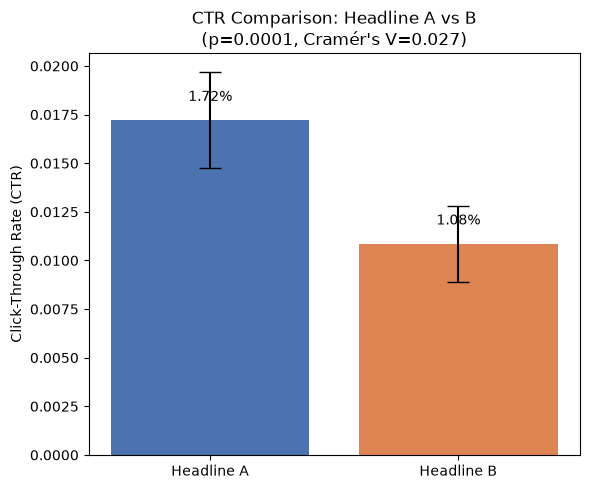
두 헤드라인의 클릭률을 95% 신뢰구간과 함께 시각화했다. 두 막대의 오차범위(error bar)가 서로 겹치지 않는 것을 확인할 수 있는데, 이는 두 그룹의 클릭률 차이가 우연이 아니라 통계적으로 유의하다는 것을 시각적으로도 뒷받침한다(카이제곱 검정 p=0.0001과 일치). 다만 y축 절대값 자체는 두 막대 모두 0.02(2%) 이하로 작다는 점에 주목해야 한다. 통계적으로 유의한 차이라고 해서 반드시 시각적·실무적으로 "큰 차이"는 아니며, 이는 Cramér's V=0.027(매우 작은 효과크기)과도 일치하는 결과다.

**해석의 핵심**: "유의하다"와 "효과가 크다"는 서로 다른 이야기라는 것을 이 그래프가 보여준다.

---

## 5. 한 걸음 더

### A. 검정력/MDE — 이 실험은 효과를 잡을 힘이 있었나

80% 검정력 기준으로, 우리 표본 크기(약 1만 명씩)로 안정적으로 탐지할 수 있는 최소 효과(MDE)를 계산했다.

- Cohen's h (MDE) = 0.0383
- **MDE = 0.432%p**
- 실제 관측된 차이 = 0.636%p

실제 관측된 차이(0.636%p)가 MDE(0.432%p)보다 크다. 즉 이 실험은 효과를 탐지할 충분한 검정력을 갖추고 있었고, 실제로 그 힘으로 유의한 차이를 잡아낸 것으로 해석할 수 있다. 표본 부족으로 우연히 유의해진 결과가 아니라는 뜻이다.

### C. 다중검정 보정 — 유의한 결과는 만들어질 수 있다

메인 검정과 동일한 구조(헤드라인 2개, 2×2 카이제곱)를 가진 실험 127개(4,871개 실험 중 헤드라인이 정확히 2개인 것만 필터링 — 3개 이상인 실험은 검정 구조가 달라 동일 비교가 불가능하므로 이번 분석 범위에서 제외)에 대해 동일한 카이제곱 검정을 반복 실행했다.

| 기준 | 유의 판정 실험 수 | 비율 |
|---|---|---|
| 보정 전 (α=0.05) | 27개 | 21.3% |
| Bonferroni 보정 후 | 5개 | 3.9% |
| BH(FDR) 보정 후 | 11개 | 8.7% |

**해석**: 보정 전 유의 비율(21.3%)이 우연이라면 나와야 할 5%보다 훨씬 높다는 것은, 헤드라인 문구가 클릭률에 실제로 영향을 주는 경우가 존재한다는 근거가 된다. 그러나 127번 반복 검정에 따른 다중검정 문제를 감안해 Bonferroni로 엄격하게 보정하면, 27개 중 22개는 우연히 유의해 보였을 가능성이 있고 5개만 확실하게 신뢰할 수 있다. BH(FDR) 기준으로는 11개가 남아 중간 수준의 신뢰도를 보인다.

우리 메인 실험의 p값(0.0001)은 Bonferroni 임계값(0.05/127 = 0.000394)보다도 작아, 127회 반복검정을 감안한 가장 엄격한 기준을 적용해도 여전히 유의하다. 즉 이번 메인 분석 결과는 다중검정으로 인한 우연한 유의성이 아니라, 보정 후에도 견고하게 살아남는 신뢰할 수 있는 결과다.

### 그래프 2: 127개 실험의 p값 분포 히스토그램

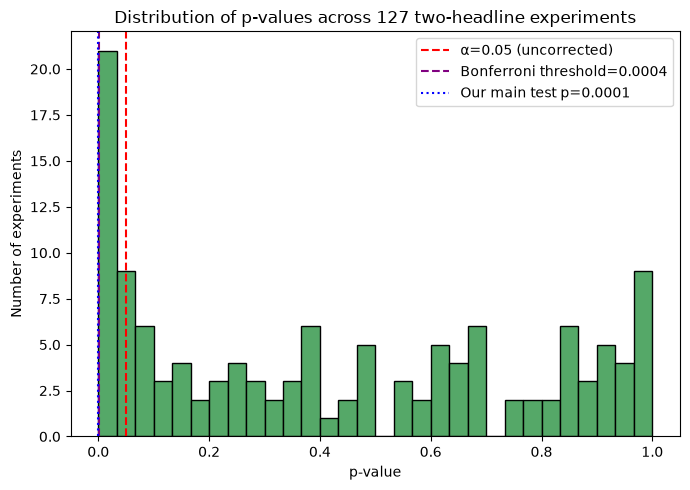
헤드라인 2개짜리 실험 127개 각각에 카이제곱 검정을 반복 실행하고 그 p값들의 분포를 그렸다. p=0 근처(맨 왼쪽)에 21개의 실험이 몰려 있는데, 만약 헤드라인이 클릭률에 아무 영향도 없었다면 p값은 0~1 사이에 균등하게 분포해야 하므로, 이렇게 0 근처에 뾰족하게 몰린 분포는 헤드라인 효과가 실제로 존재하는 실험이 상당수 있다는 신호다. α=0.05(빨간 점선)와 Bonferroni 보정 기준(보라색 점선, 0.0004) 사이에 위치한 실험들은 보정 전엔 유의했지만 다중검정을 감안하면 우연이었을 가능성이 있는 애매한 케이스에 해당한다. 우리 메인 실험의 p값(파란 점선, p=0.0001)은 이 애매한 구간이 아니라 가장 왼쪽 막대에 속해 있어, 이 결과가 우연일 가능성이 매우 낮다는 것을 다시 확인해준다. 반대로 p=1.0 근처(맨 오른쪽)에도 9개의 실험이 몰려 있는데, 이는 헤드라인 간 클릭률이 거의 완전히 동일했던 실험들이다.

---

## 6. 의사결정으로 마무리

### 1) 질문과 가설
같은 기사에 대해 헤드라인 문구를 다르게 하면 클릭률(CTR)이 달라지는가를 알고 싶었다. H₀: 두 헤드라인 간 클릭률 차이 없음, H₁: 차이 있음. α=0.05, 양측검정으로 설정했다.

### 2) 데이터 위생 점검
원본 22,666행(4,873개 실험) → 완전중복 1행, 판정 불일치 실험 1개(4행), 극소표본 7행 제거 → 최종 22,654행(4,871개 실험). 메인 분석 대상 실험은 SRM 체크 결과 p=0.687로 배정 이상이 없음을 확인했다.

### 3) 검정 선택 근거
성공지표가 비율(클릭 여부)이고 비교집단이 2개(헤드라인 A/B)이므로 카이제곱 독립성 검정을 선택했다.

### 4) 결과
헤드라인 A(CTR 1.72%)가 B(CTR 1.08%)보다 유의하게 높았다. +0.64%p, χ²(1)=15.20, p=0.0001, Cramér's V=0.027. 상대차이는 58.6%였다. 절대차이는 작지만 표본이 커서 유의하게 잡힌 사례다.

### 5) 한계까지 고려한 심화 분석
MDE 분석 결과, 80% 검정력으로 잡을 수 있는 최소효과는 0.432%p였고 실제 관측 차이(0.636%p)가 이보다 커서 충분한 검정력 하에 나온 결과임을 확인했다. 다중검정 분석 결과, 헤드라인 2개짜리 실험 127개를 반복검정했을 때 보정 전 21.3%가 유의했으나 Bonferroni 보정 후 3.9%만 남았다. 이는 개별 유의성 하나만으로 일반화하는 것이 위험하다는 것을 보여주며, 우리 메인 실험은 Bonferroni 임계값(0.000394)보다도 p값이 작아 보정 후에도 견고하게 유의함을 확인했다.

### 6) 의사결정
**도입(헤드라인 A로 확정)**을 제안한다. 통계적 유의성뿐 아니라 다중검정 보정과 MDE 검증까지 거쳐 신뢰도가 확보됐기 때문이다. 다만 효과크기가 작다(Cramér's V=0.027, 절대차이 0.64%p)는 점을 함께 보고해, "58.6% 상승"이라는 상대적 수치만으로 과장 해석하지 않도록 유의해야 한다. 실무적으로는 클릭 1건을 늘리는 데 드는 비용 대비 실익이 크지 않을 수 있으므로, 헤드라인 A/B 테스트 운영에 드는 비용이 낮은 경우에만 이 결론을 실행에 옮기는 것이 합리적이다.

### 7) 한계
- 이 데이터는 실험 하나 단위로는 무작위 배정이 보장되지만, 분석 대상 실험을 CTR 차이가 있는 것으로 미리 훑어보고 선택했다는 선택편향이 있다. 완전한 사전등록 설계는 아니었다.
- 효과크기가 작아, 실제 클릭 1건을 늘리는 데 드는 비용(헤드라인 제작·테스트 운영 인력·시간) 대비 실익은 별도로 따져봐야 한다. 본 분석에서는 비용분석(5단계 D)은 다루지 않았다.
- 이 결론은 이 특정 기사(실험 `5149d406c7a0fc0002006599`)에 대한 것이며, 다른 기사·다른 헤드라인 쌍에 그대로 일반화할 수는 없다. 실제로 127개 실험 중 다수는 유의하지 않았다.
- 다중검정 분석은 헤드라인이 정확히 2개인 실험(127개)에 한정했다. 헤드라인이 3개 이상인 나머지 4,744개 실험은 검정 구조가 달라(ANOVA 등 별도 방법 필요) 이번 분석에 포함하지 않았다.
- 데이터 출처가 공식 배포 채널이 아닌 제3자 GitHub 미러이므로, 원본과의 완전한 동일성은 별도로 검증되지 않았다(다만 컬럼 구조와 값 범위는 공개된 데이터 설명과 일치함을 확인했다).

---

*분석 도구: Python (pandas, scipy.stats, statsmodels, matplotlib)*
*데이터 출처: Upworthy Research Archive (exploratory package), 2026-07-31 확보*
